<a href="https://colab.research.google.com/github/Doan-Truc/Doan-Truc/blob/main/preprocessing-prethe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import json
from collections import Counter
from scipy.signal import butter, filtfilt, welch
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import os


In [ ]:
fs = 128  # Sampling rate
run_names = ['Run1', 'Run2', 'Run3', 'Run4', 'Run5','Run6','Run7','Run8']

# Lấy đúng các nhãn hành động MI
valid_labels = ['3', '4', '5', '6']
label_map = {
    '3': 'Right Hand',
    '4': 'Left Hand',
    '5': 'Right Foot',
    '6': 'Left Foot'
}


Bandpass, ICA, Chuẩn hoá

In [ ]:
import os
import json
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA

# ==== CONFIG ====
fs = 128  # Sampling rate (Hz)
run_names = ['Run1', 'Run2', 'Run3', 'Run4', 'Run5', 'Run6', 'Run7', 'Run8']

base_path = "/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024"
output_dir = os.path.join(base_path, "cleaned_full_runs")
os.makedirs(output_dir, exist_ok=True)

# === Label mapping (motor imagery actions only) ===
label_map = {
    '1': 'Rest',
    '2': 'Cue',
    '3': 'Right Hand',
    '4': 'Left Hand',
    '5': 'Right Foot',
    '6': 'Left Foot'
}

# ==== FILTER FUNCTIONS ====
def bandpass_filter(eeg, low=8, high=30, fs=128, order=4):
    """Lọc EEG giữ dải tần 8–30 Hz"""
    b, a = butter(order, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, eeg, axis=0)

def apply_ica(eeg, n_components=None):
    """Giảm nhiễu bằng ICA"""
    ica = FastICA(n_components=n_components or eeg.shape[1], random_state=42)
    return ica.fit_transform(eeg)

def normalize(eeg):
    """Chuẩn hoá dữ liệu EEG (z-score)"""
    scaler = StandardScaler()
    return scaler.fit_transform(eeg)

# ==== MAIN PIPELINE ====
for run in run_names:
    print(f"\n🧠 Processing {run} ...")

    # === Load files ===
    csv_file = os.path.join(base_path, f"{run}_Raw Signals.csv")
    label_file = os.path.join(base_path, f"{run}_Action label.txt")
    event_file = os.path.join(base_path, f"{run}_Event timestamp.txt")
    json_file = os.path.join(base_path, f"{run}_Session setup.json")

    # Kiểm tra đủ file
    if not all(os.path.exists(f) for f in [csv_file, label_file, event_file, json_file]):
        print(f"Missing file(s) for {run}, skipping...")
        continue

    eeg = pd.read_csv(csv_file, header=None).iloc[:, :22].values
    labels = [line.strip() for line in open(label_file)]
    events = [int(line.strip()) for line in open(event_file)]
    session_info = json.load(open(json_file))

    # === Step 1: Bandpass filter (8–30 Hz) ===
    eeg_filtered = bandpass_filter(eeg, low=8, high=30, fs=fs)

    # === Step 2: ICA artifact removal ===
    eeg_ica = apply_ica(eeg_filtered)

    # === Step 3: Normalization ===
    eeg_norm = normalize(eeg_ica)

    # === Step 4: Save cleaned full EEG ===
    save_path = os.path.join(output_dir, f"{run}_cleaned_full.npy")
    np.save(save_path, {
        "eeg_clean": eeg_norm,
        "labels": labels,
        "events": events,
        "sampling_rate": fs,
        "channel_count": eeg_norm.shape[1]
    })

    print(f"Saved cleaned EEG for {run}: {save_path}")
    print(f"   → Shape: {eeg_norm.shape}, Labels: {len(labels)}, Events: {len(events)}")

print("\n All runs processed and saved successfully!")



🧠 Processing Run1 ...
Saved cleaned EEG for Run1: /content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/cleaned_full_runs/Run1_cleaned_full.npy
   → Shape: (12289, 22), Labels: 36, Events: 12

🧠 Processing Run2 ...
Saved cleaned EEG for Run2: /content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/cleaned_full_runs/Run2_cleaned_full.npy
   → Shape: (12289, 22), Labels: 36, Events: 12

🧠 Processing Run3 ...
Saved cleaned EEG for Run3: /content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/cleaned_full_runs/Run3_cleaned_full.npy
   → Shape: (12289, 22), Labels: 36, Events: 11

🧠 Processing Run4 ...
Saved cleaned EEG for Run4: /content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/cleaned_full_runs/Run4_cleaned_full.npy
   → Shape: (12289, 22), Labels: 36, Events: 11

🧠 Processing Run5 ...
Saved cleaned EEG for Run5: /content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/cleaned_full_runs/Run5_cleaned_full.npy
   → Shape: (12289, 22), Labels: 36, Events: 12

🧠 Pr

In [ ]:
import numpy as np

data = np.load("/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/cleaned_full_runs/Run1_cleaned_full.npy", allow_pickle=True).item()

eeg = data["eeg_clean"]
labels = data["labels"]
events = data["events"]

print(eeg.shape)       # (samples, 22)
print(labels[:36])     # ['1', '2', '3', ...]
print(events[:12])      # [352, 1344, 2656, ...]


(12289, 22)
['1', '2', '3', '1', '2', '4', '1', '2', '5', '1', '2', '6', '1', '2', '3', '1', '2', '4', '1', '2', '5', '1', '2', '6', '1', '2', '3', '1', '2', '4', '1', '2', '5', '1', '2', '6']
[352, 1376, 2400, 3456, 4416, 5472, 6496, 7552, 8576, 9568, 10592, 11616]


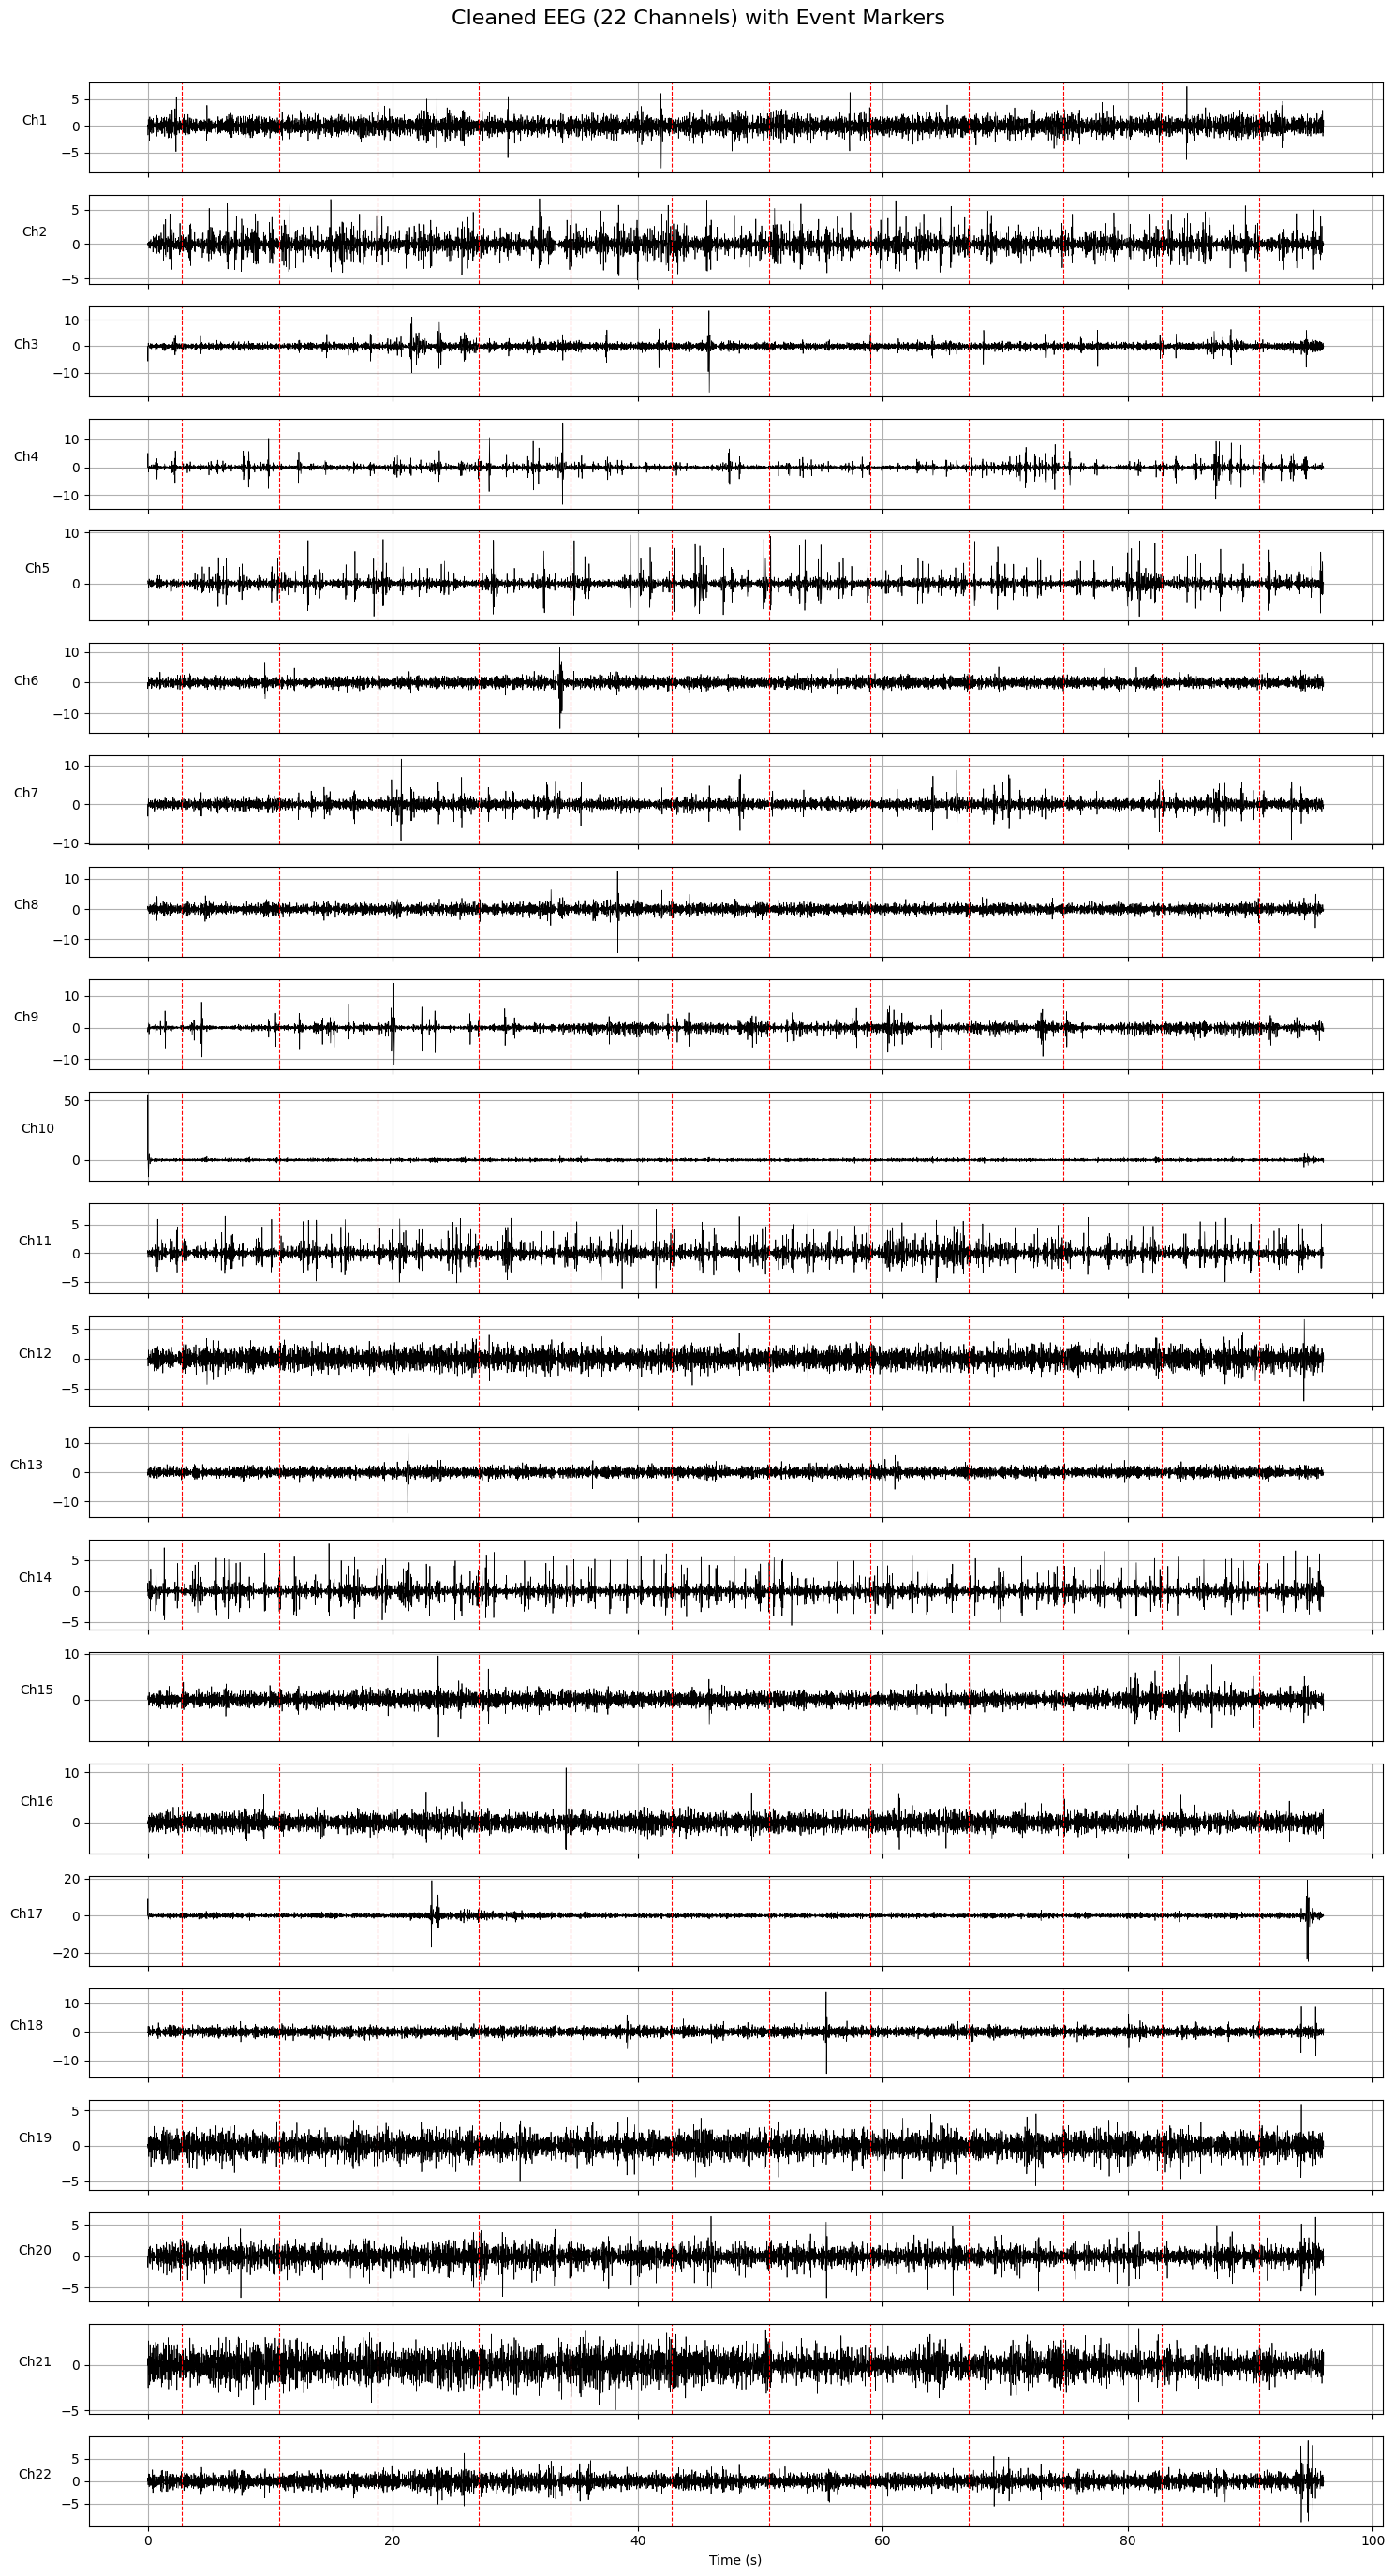

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Load EEG data ====
data_path = "/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/cleaned_full_runs/Run1_cleaned_full.npy"
data = np.load(data_path, allow_pickle=True).item()

eeg = data["eeg_clean"]          # (samples, 22)
labels = data["labels"]          # list các nhãn hành động
events = data["events"]          # timestamp bắt đầu trial (đơn vị sample)
fs = data["sampling_rate"]       # 128 Hz
n_channels = data["channel_count"]

# ==== Tạo vector thời gian ====
time = np.arange(eeg.shape[0]) / fs  # giây

# ==== Khai báo mapping nhãn ====
label_map = {
    '1': 'Rest',
    '2': 'Cue',
    '3': 'Right Hand',
    '4': 'Left Hand',
    '5': 'Right Foot',
    '6': 'Left Foot'
}

# ==== Vẽ EEG 22 kênh ====
fig, axs = plt.subplots(n_channels, 1, figsize=(15, 28), sharex=True)

for i in range(n_channels):
    axs[i].plot(time, eeg[:, i], lw=0.5, color='black')
    axs[i].set_ylabel(f"Ch{i+1}", rotation=0, labelpad=20)
    axs[i].grid(True)

# ==== Thêm marker cho các event ====
for idx, ev in enumerate(events):
    ev_time = ev / fs
    label_idx = idx * 4 + 2  # MI action thứ 3 trong 4 hành động mỗi trial
    if label_idx < len(labels):
        label = label_map.get(labels[label_idx], "Unknown")
    else:
        label = "Unknown"

    for ax in axs:
        ax.axvline(ev_time, color='red', linestyle='--', lw=0.8)
        """ax.text(ev_time + 0.2, ax.get_ylim()[1]*0.8, label, color='blue', fontsize=6)"""

axs[-1].set_xlabel("Time (s)")
plt.suptitle("Cleaned EEG (22 Channels) with Event Markers", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 47.7 MB/s eta 0:00:00


ID1 RUN2

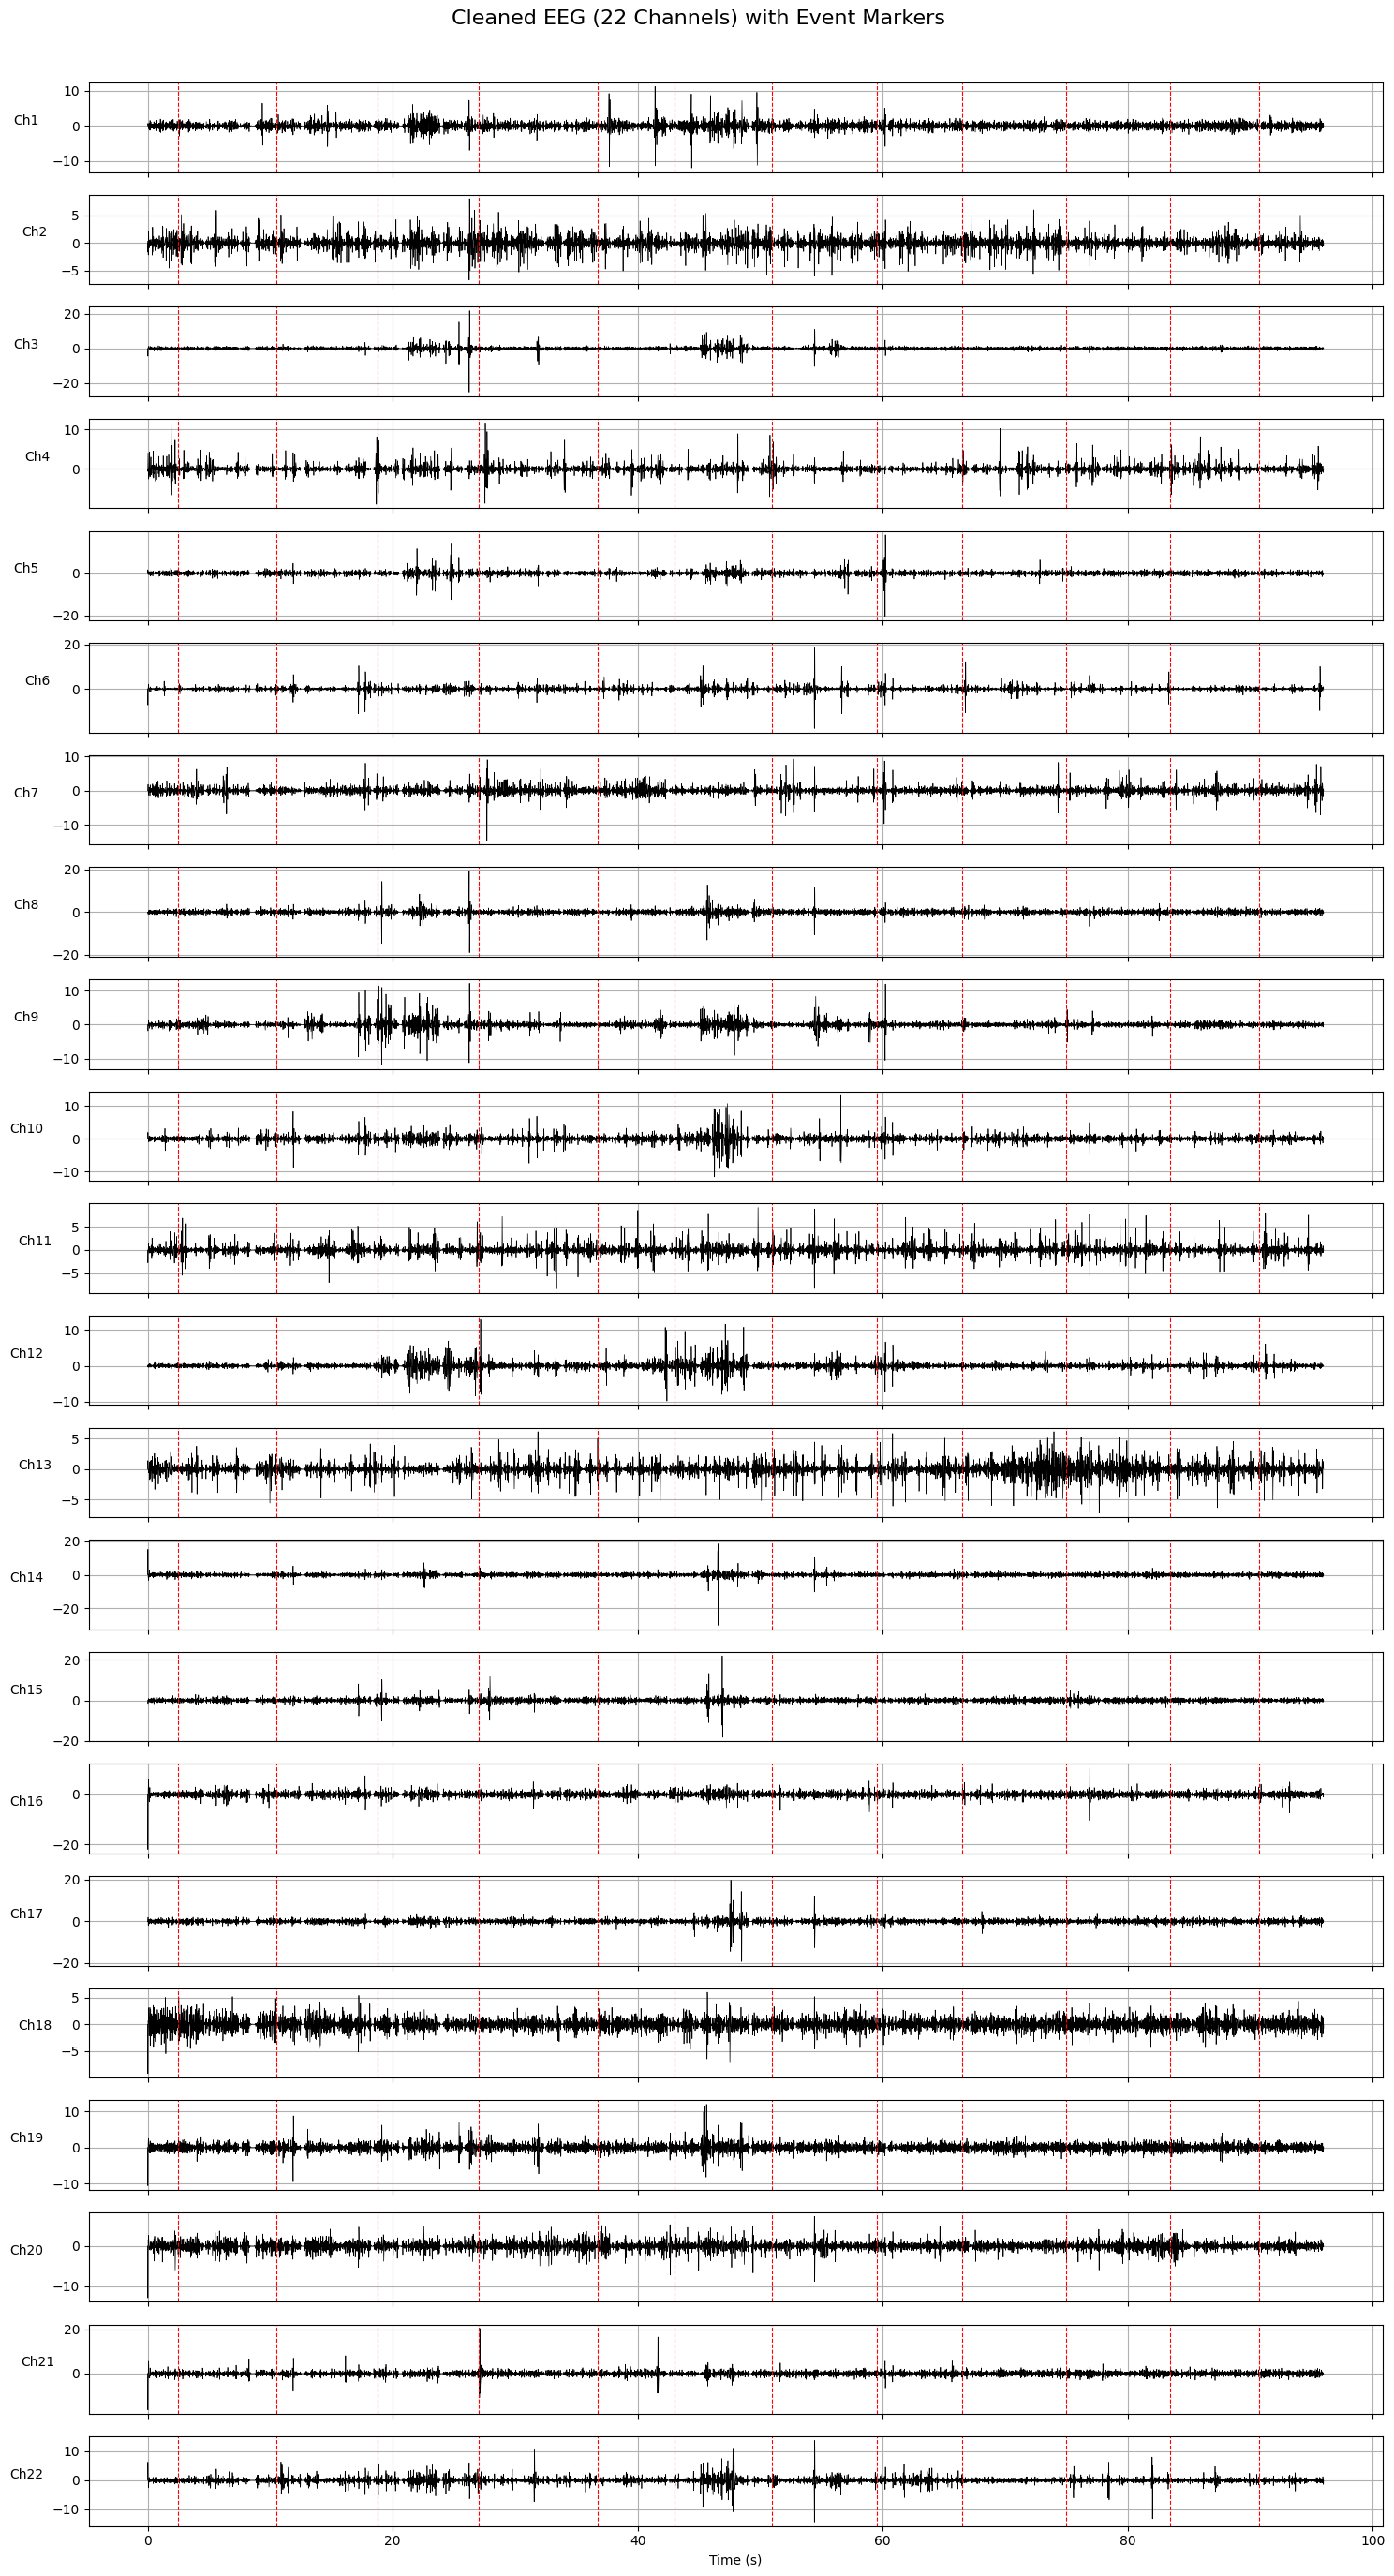

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Load EEG data ====
data_path = "/content/drive/MyDrive/truc/Data_UET175/ID01/S01_11_12_2024/cleaned_full_runs/Run2_cleaned_full.npy"
data = np.load(data_path, allow_pickle=True).item()

eeg = data["eeg_clean"]          # (samples, 22)
labels = data["labels"]          # list các nhãn hành động
events = data["events"]          # timestamp bắt đầu trial (đơn vị sample)
fs = data["sampling_rate"]       # 128 Hz
n_channels = data["channel_count"]

# ==== Tạo vector thời gian ====
time = np.arange(eeg.shape[0]) / fs  # giây

# ==== Khai báo mapping nhãn ====
label_map = {
    '1': 'Rest',
    '2': 'Cue',
    '3': 'Right Hand',
    '4': 'Left Hand',
    '5': 'Right Foot',
    '6': 'Left Foot'
}

# ==== Vẽ EEG 22 kênh ====
fig, axs = plt.subplots(n_channels, 1, figsize=(15, 28), sharex=True)

for i in range(n_channels):
    axs[i].plot(time, eeg[:, i], lw=0.5, color='black')
    axs[i].set_ylabel(f"Ch{i+1}", rotation=0, labelpad=20)
    axs[i].grid(True)

# ==== Thêm marker cho các event ====
for idx, ev in enumerate(events):
    ev_time = ev / fs
    label_idx = idx * 4 + 2  # MI action thứ 3 trong 4 hành động mỗi trial
    if label_idx < len(labels):
        label = label_map.get(labels[label_idx], "Unknown")
    else:
        label = "Unknown"

    for ax in axs:
        ax.axvline(ev_time, color='red', linestyle='--', lw=0.8)
        """ax.text(ev_time + 0.2, ax.get_ylim()[1]*0.8, label, color='blue', fontsize=6)"""

axs[-1].set_xlabel("Time (s)")
plt.suptitle("Cleaned EEG (22 Channels) with Event Markers", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [ ]:
!pip install bctpy networkx matplotlib numpy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import bct

# ==============================
# 1️⃣ Load weighted matrix
# ==============================
conn_matrix = np.loadtxt("/content/Run1_MVAR_dTF_weighted_matrix.csv", delimiter=",")

# Đặt tên 22 kênh EEG (bạn có thể chỉnh theo thứ tự thực tế)
channels = ['Cz','FCz','Fz','FC1','C1','C3','FC3','C5','CP3','CP1','P1','CPz','Pz','POz','P2','CP2','CP4','C6','FC4','C4','C2','FC2']

# ==============================
# 2️⃣ Normalize + Threshold (giữ top 30%)
# ==============================
# Chuẩn hoá
norm_matrix = conn_matrix / np.max(conn_matrix)

# Lấy ngưỡng top 30%
threshold = np.percentile(norm_matrix, 70)
binary_matrix = np.where(norm_matrix >= threshold, norm_matrix, 0)

print(f"Threshold value: {threshold:.4f}")
print(f"Remaining connections: {np.count_nonzero(binary_matrix)} / {binary_matrix.size}")

# ==============================
# 3️⃣ Phân tích bằng BCT
# ==============================
degree = bct.degrees_und(binary_matrix)
clustering = bct.clustering_coef_wu(binary_matrix)
efficiency = bct.efficiency_wei(binary_matrix)

print("Degree:", degree)
print("Global Efficiency:", np.mean(efficiency))

# ==============================
# 4️⃣ Visualization Graph
# ==============================
G = nx.from_numpy_array(binary_matrix, create_using=nx.DiGraph)

# Set node labels
label_dict = {i: ch for i, ch in enumerate(channels)}

# Layout: hình tròn / vị trí EEG tùy chọn
pos = nx.circular_layout(G)  # bạn có thể dùng layout 3D EEG thực tế sau

# Vẽ đồ thị
plt.figure(figsize=(8,8))
edges = G.edges(data=True)

# Tô màu theo trọng số
weights = [d['weight'] for (u, v, d) in edges]
nx.draw(G, pos, with_labels=True, labels=label_dict,
        node_size=800, node_color='lightblue',
        font_size=8, width=np.array(weights)*5, edge_color=weights,
        edge_cmap=plt.cm.viridis)

plt.title("Brain Connectivity Graph (Thresholded dTF Network)", fontsize=12)
plt.show()
